# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE # pip install imbalanced-learn
from collections import Counter
from sklearn.linear_model import LogisticRegression
import time
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

## Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



## Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Based on the text provided, the data represents **17** campaigns.

Here are the key details surrounding those campaigns as mentioned in the article:

- **Timeframe:** They occurred between May 2008 and November 2010.
- **Total Contacts:** 79,354 contacts were made across these campaigns.
- **Successes:** There were 6,499 successful outcomes (an 8% success rate).
- **Product Offered:** A long-term deposit application with attractive interest rates.
- **Primary Channel:** Telephone (human agents), with occasional auxiliary use of online banking.

In [3]:
17

17

## Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [4]:
df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep = ';')

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.shape

(41188, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Missing Values and Data Types Analysis

**Missing Values:**

*   The `df.info()` output indicates that all columns have `41188` non-null entries, matching the total number of rows. This means there are no explicit `NaN` values in the dataset.
*   However, the data description reveals that several categorical features use the string `'unknown'` to denote missing information. These include `job`, `marital`, `education`, `default`, `housing`, and `loan`. These 'unknown' values will need to be addressed as a form of missing data during feature engineering.

**Data Types:**

*   Numerical columns (`age`, `duration`, `campaign`, `pdays`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) are correctly identified as `int64` or `float64`.
*   Categorical columns are identified as `object` type, which is appropriate before encoding.
*   The target variable `y` is also of `object` type ('yes'/'no') and will need to be converted to a numerical representation (e.g., 0 for 'no', 1 for 'yes') for most machine learning models.

**Special Consideration for `duration`:**

*   As noted in the data description, the `duration` column highly influences the output and is not known before a call. Therefore, it should be excluded from a realistic predictive model and only used for benchmark purposes.

In [9]:
print('Checking for \'unknown\' values in categorical columns:')
for column in df.select_dtypes(include=['object', 'category']).columns.tolist():
    if 'unknown' in df[column].unique():
        print(f"  Column '{column}' contains '{df[column].value_counts()['unknown']}' 'unknown' values in {df[column].size}")
    else:
        print(f"  Column '{column}' does not contain 'unknown' values.")

Checking for 'unknown' values in categorical columns:
  Column 'job' contains '330' 'unknown' values in 41188
  Column 'marital' contains '80' 'unknown' values in 41188
  Column 'education' contains '1731' 'unknown' values in 41188
  Column 'default' contains '8597' 'unknown' values in 41188
  Column 'housing' contains '990' 'unknown' values in 41188
  Column 'loan' contains '990' 'unknown' values in 41188
  Column 'contact' does not contain 'unknown' values.
  Column 'month' does not contain 'unknown' values.
  Column 'day_of_week' does not contain 'unknown' values.
  Column 'poutcome' does not contain 'unknown' values.
  Column 'y' does not contain 'unknown' values.


## Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Business Objective

The primary business Objective is to **improve the efficiency and effectiveness of a bank's direct marketing campaigns**.

The specific goals include:

- **Increasing Campaign Efficiency:** Reducing the total number of contacts required while maintaining a similar number of successful outcomes.

- **Predicting Success:** Building a predictive model to identify which clients are most likely to subscribe to a long-term deposit application.

- **Resource Management:** Helping managers better allocate resources—such as human effort, time, and budget—by targeting a high-quality set of potential customers.

- **Identifying Key Success Drivers:** Determining the specific characteristics and variables (e.g., call duration, time of year) that most significantly affect the success of a marketing contact.

## Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

### Exploratory Data Analysis

In [10]:
print("\nNumber of rows, columns:")
print(df.shape)


Number of rows, columns:
(41188, 21)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [12]:
print("\nDescriptive Statistics of Numerical Variables:")
df.select_dtypes(['int64', 'int32', 'float']).describe()


Descriptive Statistics of Numerical Variables:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [13]:
print("\nDescriptive Statistics of Categorical Variables")
df.describe(include=['object', 'category'])


Descriptive Statistics of Categorical Variables


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [14]:
# Missing values
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


### Feature Engineering

**Cleaning Missing Values**

There is no missing values.

In [15]:
# Missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0


**Handling 'unknown' values**

Based on the analysis, several categorical columns contain 'unknown' values. I will impute these 'unknown' values with the mode (most frequent value) of their respective columns. This is a common strategy for handling missing categorical data.

In [16]:
print('Checking for \'unknown\' values in categorical columns:')
columns_with_unknowns = []
for column in df.select_dtypes(include=['object', 'category']).columns.tolist():
    if 'unknown' in df[column].unique():
        columns_with_unknowns.append(column)
        print(f"  Column '{column}' contains '{df[column].value_counts()['unknown']}' 'unknown' values in {df[column].size}")

# Impute 'unknown' values with the mode for specified categorical columns
for column in columns_with_unknowns:
    # Calculate the mode, excluding 'unknown' itself if it's the mode, to get the 'true' most frequent category
    mode_value = df[df[column] != 'unknown'][column].mode()[0]
    df[column] = df[column].replace('unknown', mode_value)
    print(f"  Column '{column}': 'unknown' values replaced with '{mode_value}'")

print('\nVerifying no more ''unknown'' values in these columns:')
for column in columns_with_unknowns:
    if 'unknown' in df[column].unique():
        print(f"  Column '{column}' still contains 'unknown' values.")
    else:
        print(f"  Column '{column}' successfully processed.")

Checking for 'unknown' values in categorical columns:
  Column 'job' contains '330' 'unknown' values in 41188
  Column 'marital' contains '80' 'unknown' values in 41188
  Column 'education' contains '1731' 'unknown' values in 41188
  Column 'default' contains '8597' 'unknown' values in 41188
  Column 'housing' contains '990' 'unknown' values in 41188
  Column 'loan' contains '990' 'unknown' values in 41188
  Column 'job': 'unknown' values replaced with 'admin.'
  Column 'marital': 'unknown' values replaced with 'married'
  Column 'education': 'unknown' values replaced with 'university.degree'
  Column 'default': 'unknown' values replaced with 'no'
  Column 'housing': 'unknown' values replaced with 'yes'
  Column 'loan': 'unknown' values replaced with 'no'

Verifying no more unknown values in these columns:
  Column 'job' successfully processed.
  Column 'marital' successfully processed.
  Column 'education' successfully processed.
  Column 'default' successfully processed.
  Column 'ho

**Cleaning High Correlated Fields**

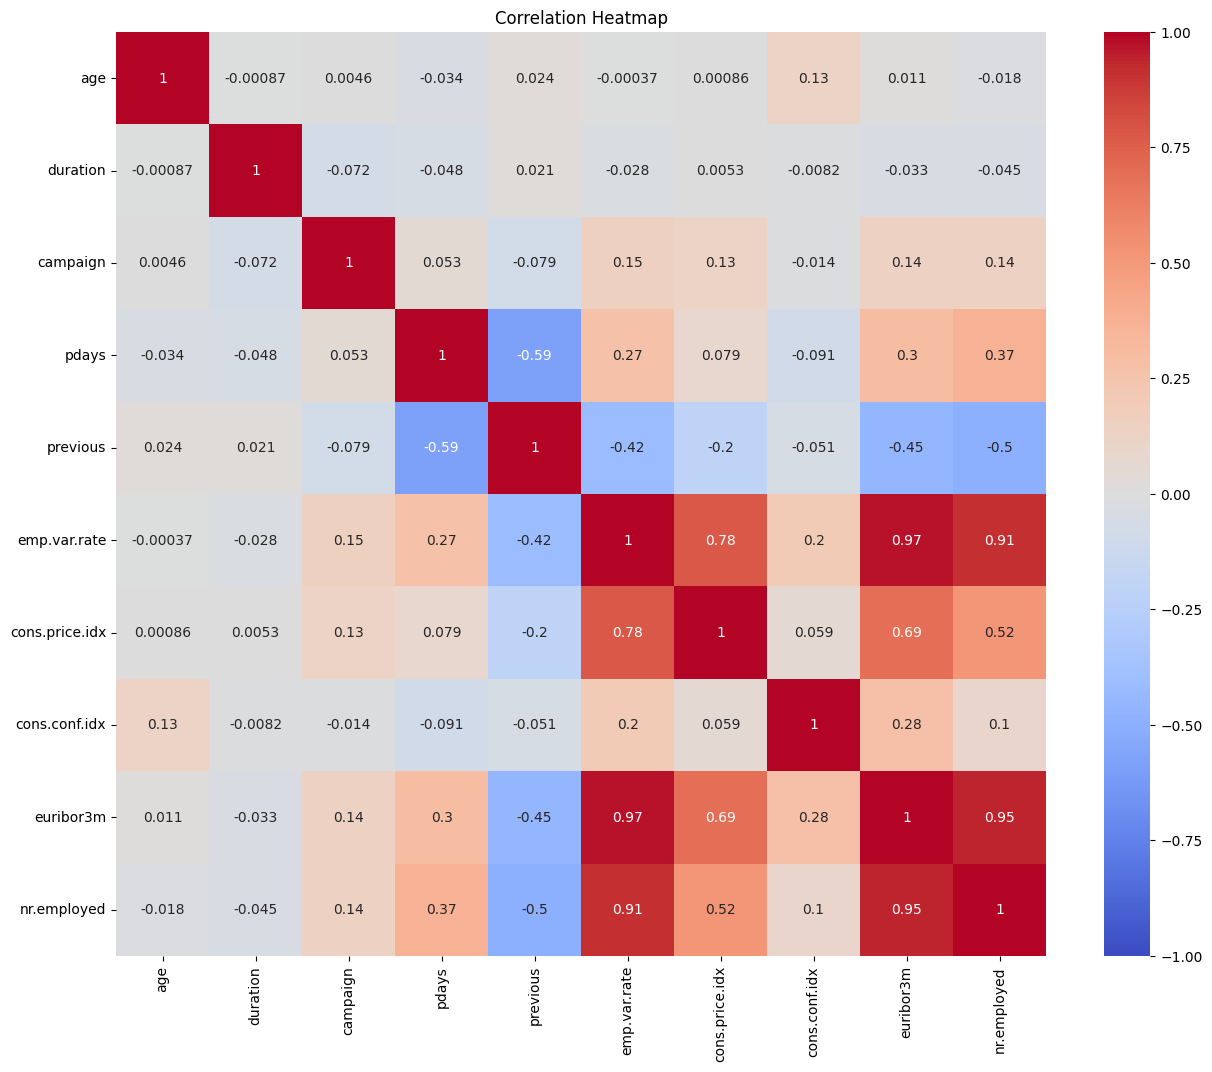

In [17]:
# Selecting numerical features only
df_numeric = df.select_dtypes(include=['float64', 'int64', 'int32'])

# Heatmap on numerical features
plt.figure(figsize=(15, 12))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

Defining a threshold and dropping highly correlated features.

In [18]:
# Re-select numerical features from raw_data
df_numeric = df.select_dtypes(include=['float64', 'int64', 'int32'])

# Recalculate the correlation matrix
corr_matrix = df_numeric.corr().abs()

threshold_corr = 0.70

# Filter for correlations greater than threshold_corr, excluding self-correlations
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_tri[upper_tri > threshold_corr].stack()

print(f"Columns with correlation greater than {threshold_corr} in raw_data:")
display(high_corr_pairs.sort_values(ascending=False))

# Identify columns to drop
columns_to_drop_from_raw_data = set()

for idx, correlation_value in high_corr_pairs.items():
    col1, col2 = idx[0], idx[1]
    if col2 not in columns_to_drop_from_raw_data:
        columns_to_drop_from_raw_data.add(col2)
        print(f"Dropping '{col2}' (correlated with '{col1}', correlation: {correlation_value:.2f})")

if columns_to_drop_from_raw_data:
    print(f"\nIdentified columns to drop: {list(columns_to_drop_from_raw_data)}")
    df = df.drop(columns=list(columns_to_drop_from_raw_data))
    print(f"Dropped {len(columns_to_drop_from_raw_data)} highly correlated columns.")
    print(f"New shape of raw_data: {df.shape}")
else:
    print("\nNo highly correlated columns (above threshold) found to drop.")

Columns with correlation greater than 0.7 in raw_data:


emp.var.rate  euribor3m         0.972245
euribor3m     nr.employed       0.945154
emp.var.rate  nr.employed       0.906970
              cons.price.idx    0.775334
dtype: float64

Dropping 'cons.price.idx' (correlated with 'emp.var.rate', correlation: 0.78)
Dropping 'euribor3m' (correlated with 'emp.var.rate', correlation: 0.97)
Dropping 'nr.employed' (correlated with 'emp.var.rate', correlation: 0.91)

Identified columns to drop: ['cons.price.idx', 'euribor3m', 'nr.employed']
Dropped 3 highly correlated columns.
New shape of raw_data: (41188, 18)


Visualizing remaining numerical features

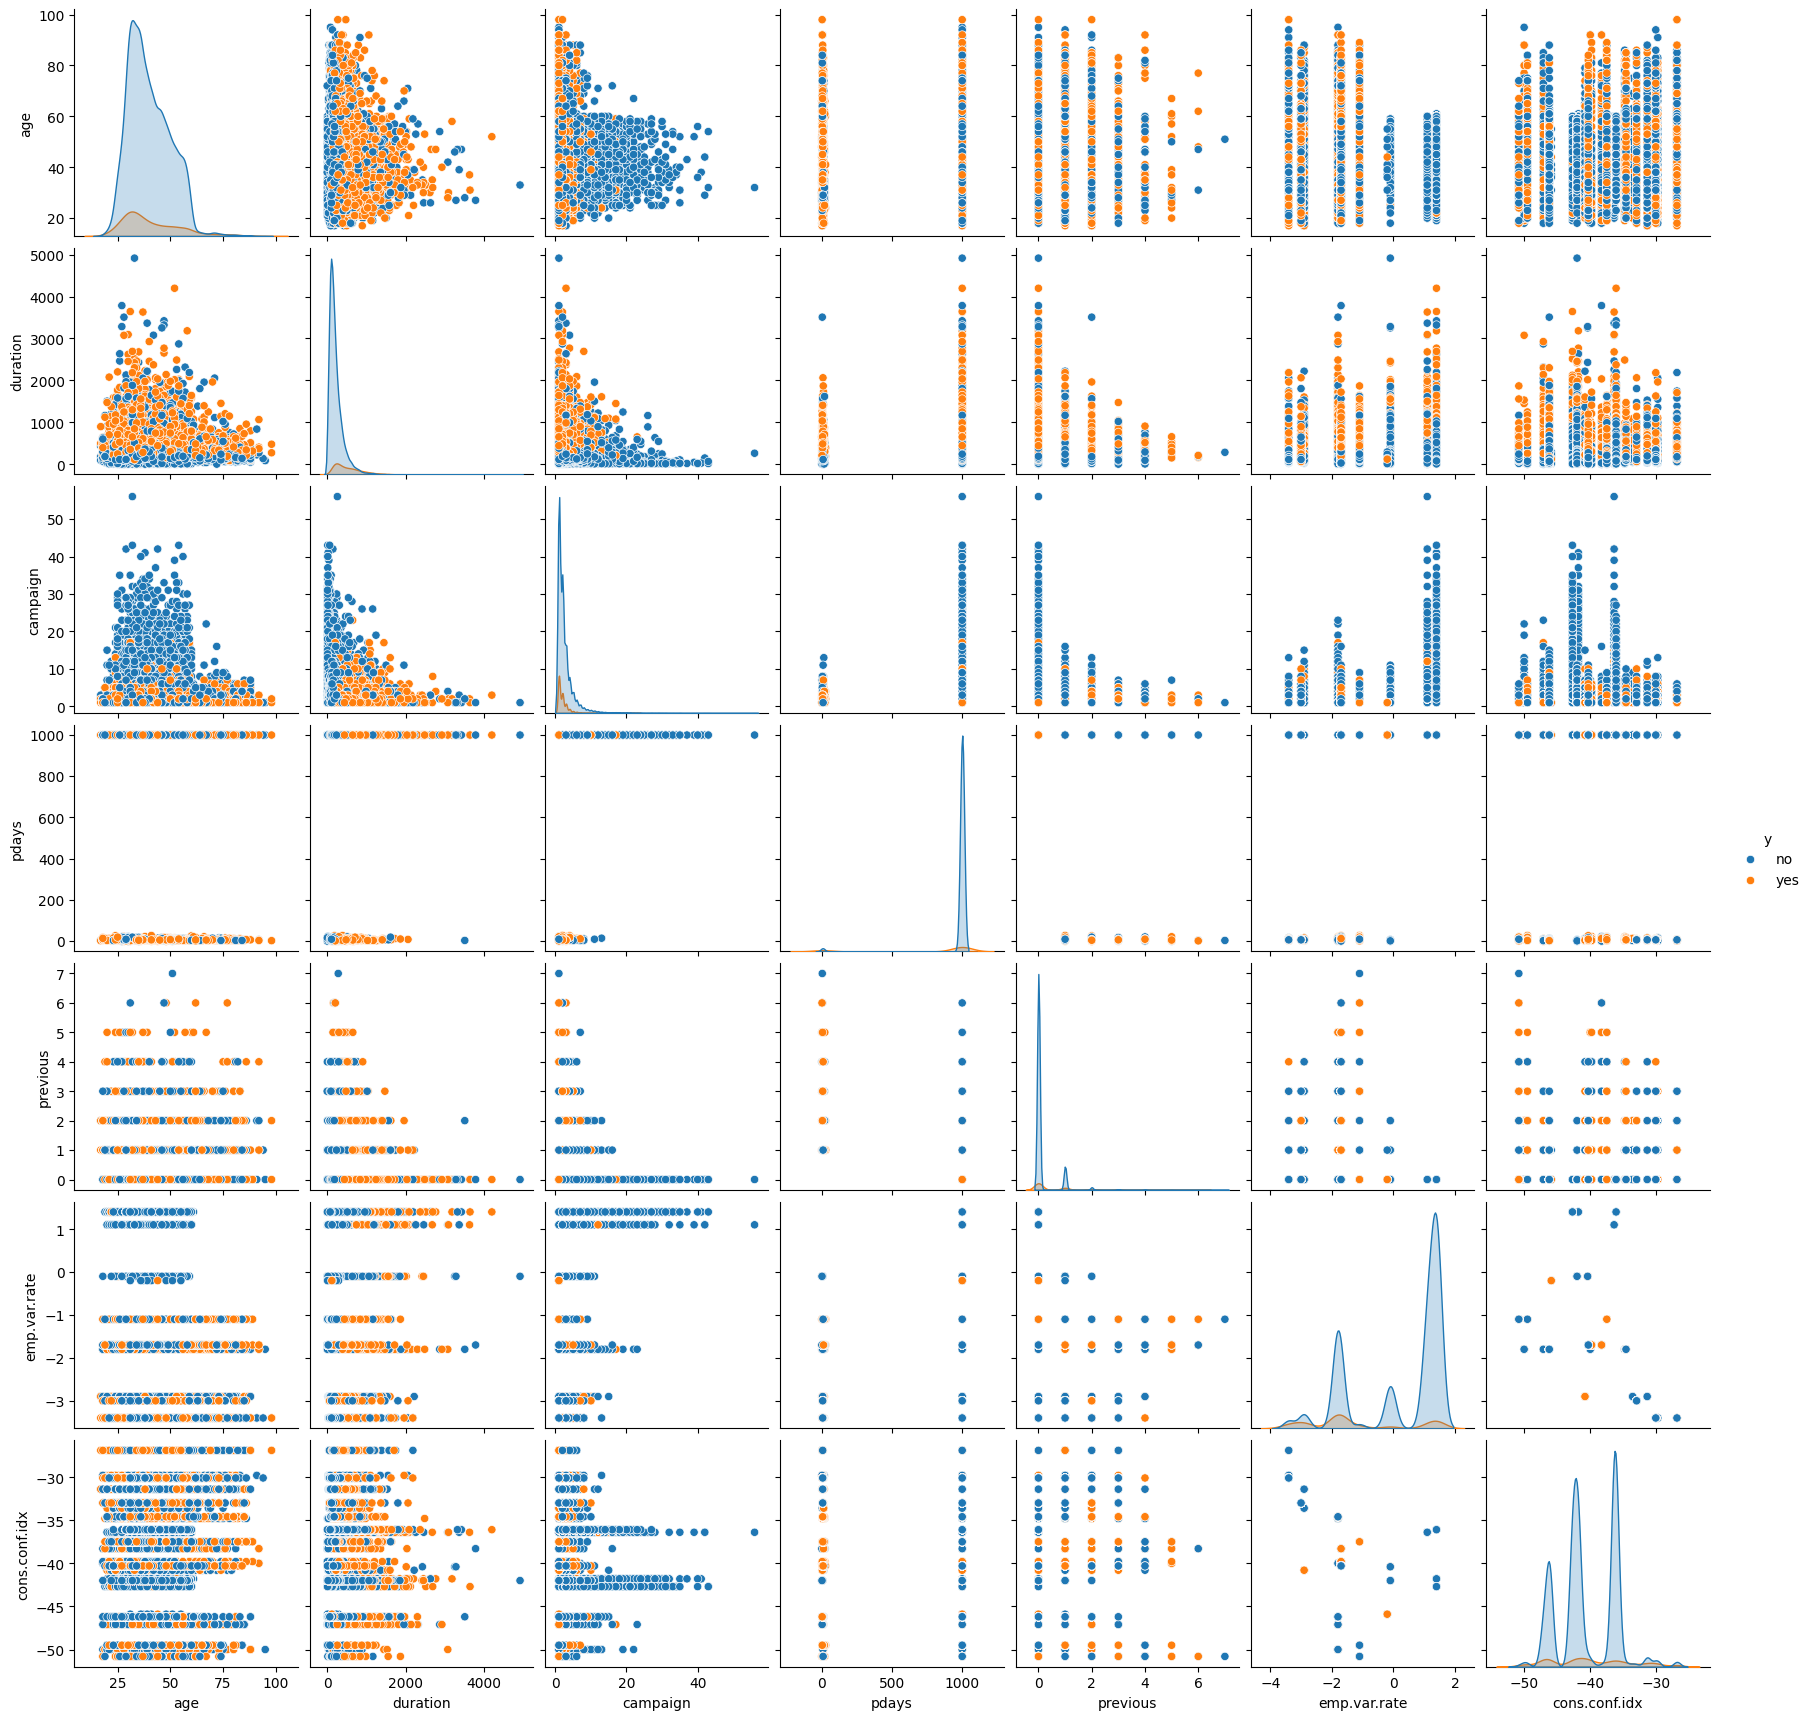

In [19]:
# Create a pairplot for all numerical variables, coloring by the 'y' variable.
sns.pairplot(df, hue='y')
plt.show()

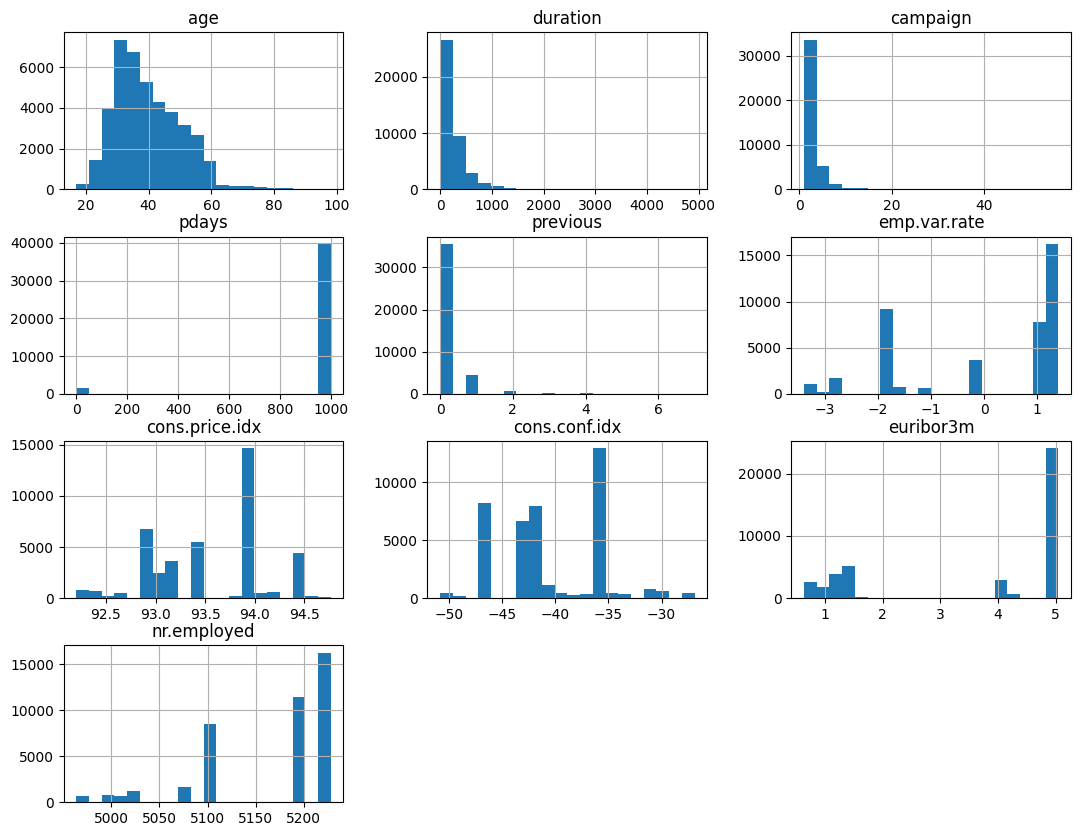

In [20]:
# Histogram for numerical variables
df_numeric.hist(bins=20, figsize=(13, 10))
plt.show()

**Investigating High Cardinality**

Distinguishing between categorical features with low and high cardinality before applying one-hot encoding.

In [21]:
def analyzeCardinality(X, max_distinct_values):
  # Identify all object (categorical) columns
  all_categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

  # Determine high and low cardinality columns based on a threshold (e.g., > max_distinct_values unique values)
  high_cardinality_cols = []
  low_cardinality_cols = []

  for col in all_categorical_cols:
      if X[col].nunique() > max_distinct_values:
          high_cardinality_cols.append(col)
      else:
          low_cardinality_cols.append(col)

  print(f"Low cardinality columns for One-Hot Encoding: {low_cardinality_cols}")
  print(f"High cardinality columns for Frequency Encoding: {high_cardinality_cols}")
  return low_cardinality_cols, high_cardinality_cols

In [22]:
analyzeCardinality(df, 25)

Low cardinality columns for One-Hot Encoding: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
High cardinality columns for Frequency Encoding: []


(['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome',
  'y'],
 [])

Looks like we don't have any category which has more than 25 distinct values. Hence we can apply one-hot encoding to all categorical features.

**Visualizing categorical features**

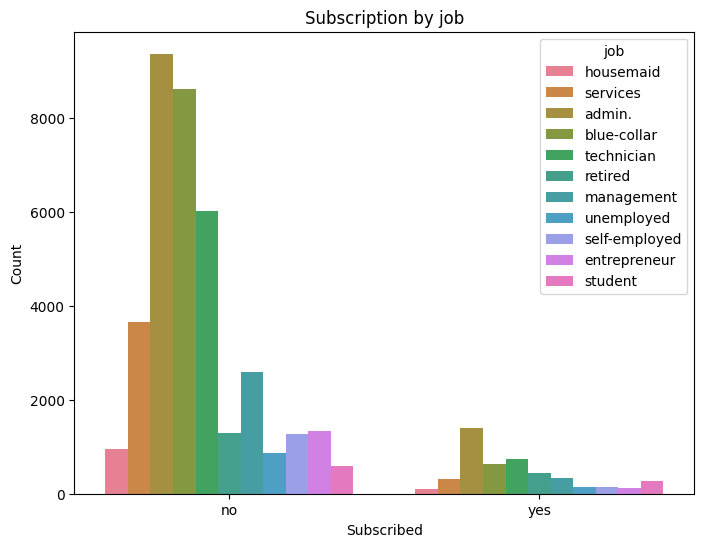

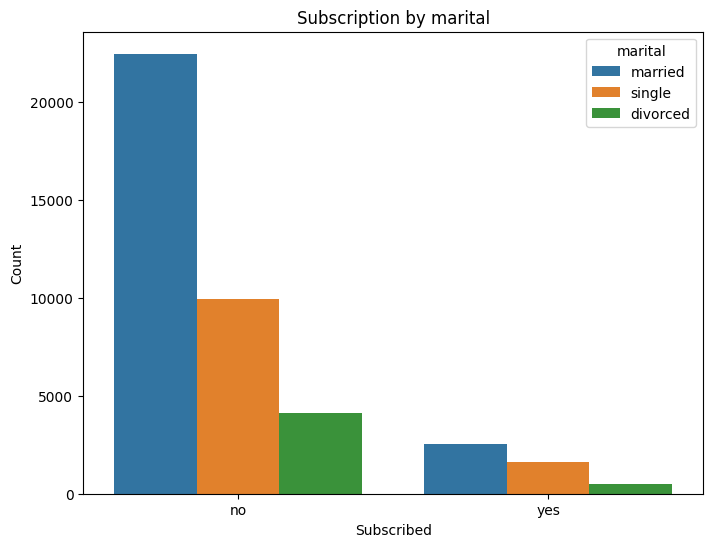

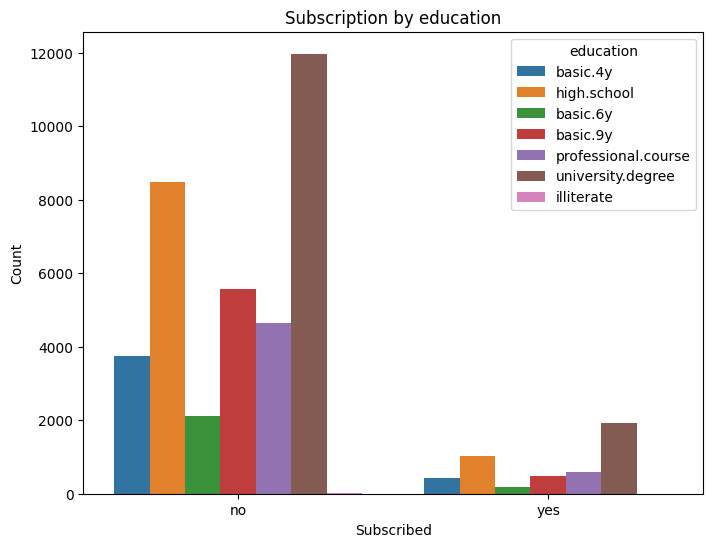

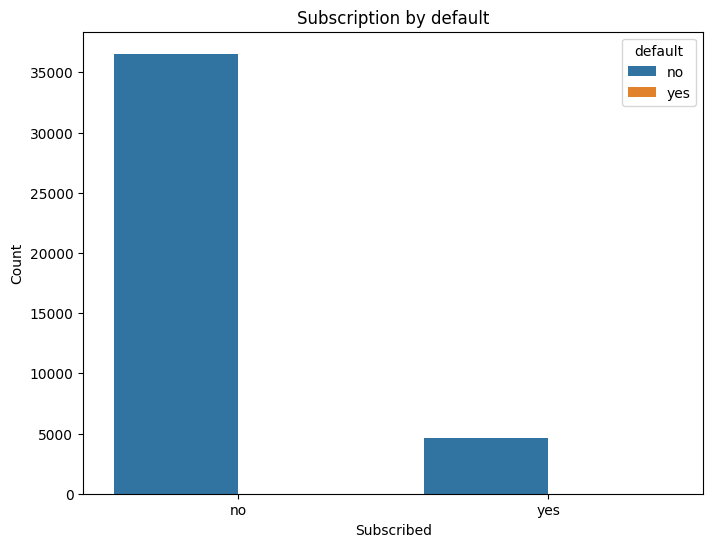

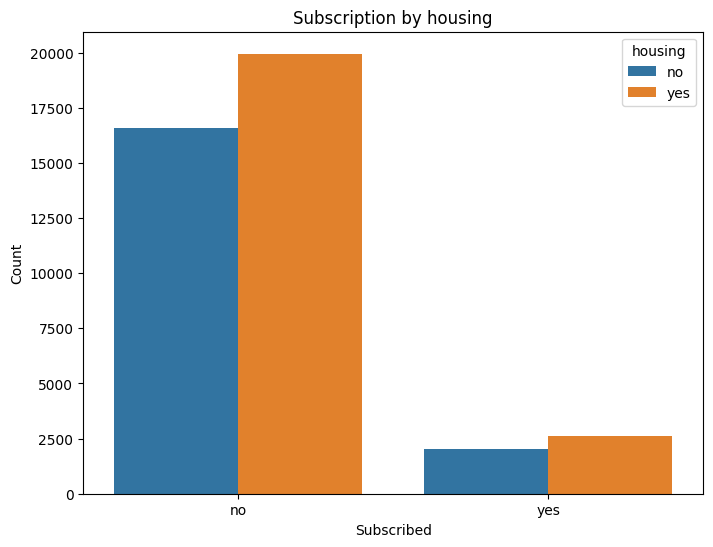

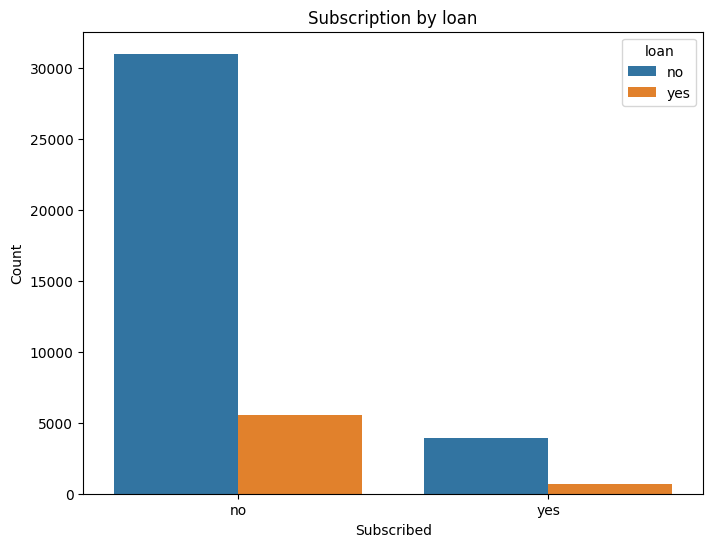

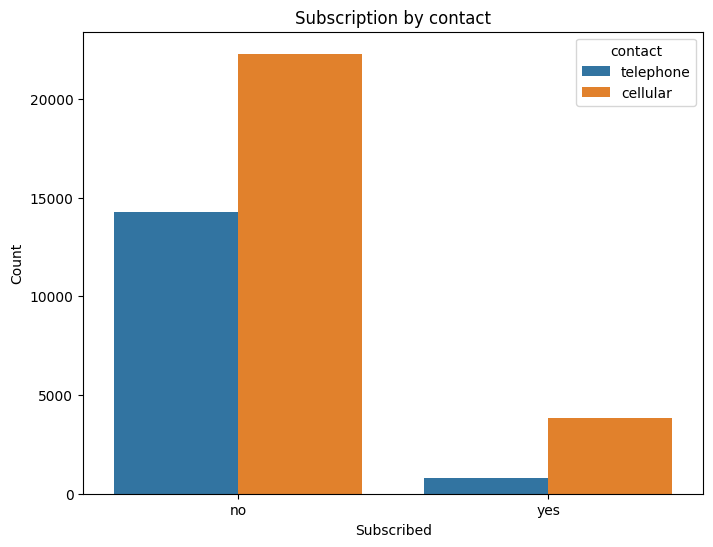

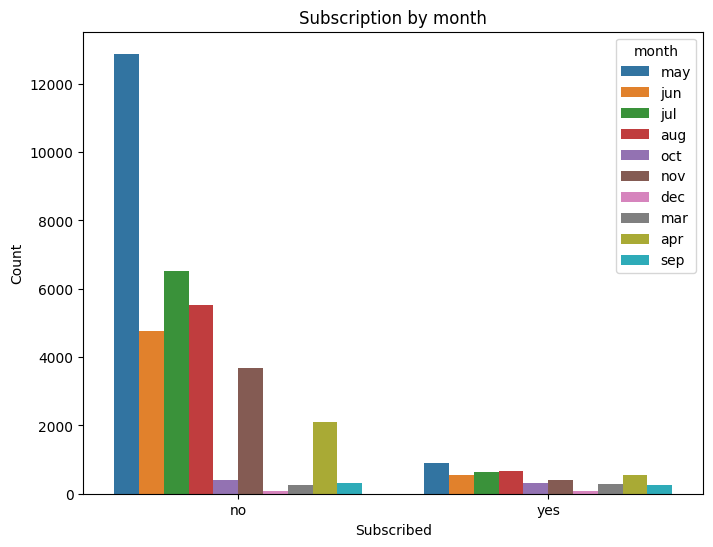

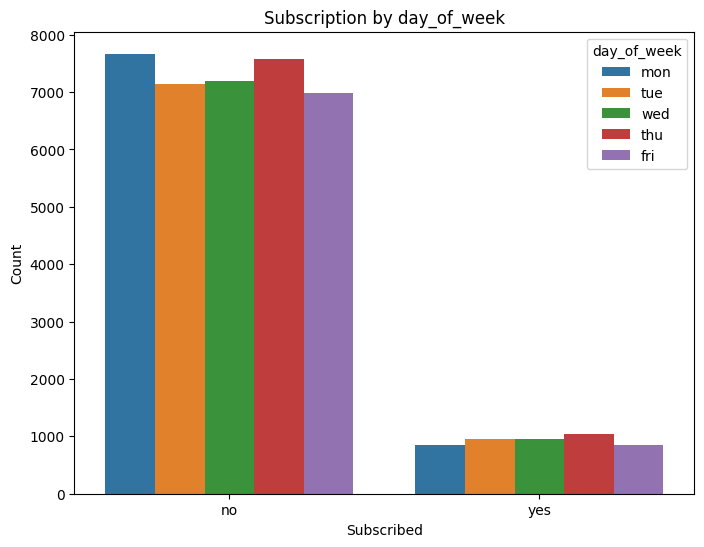

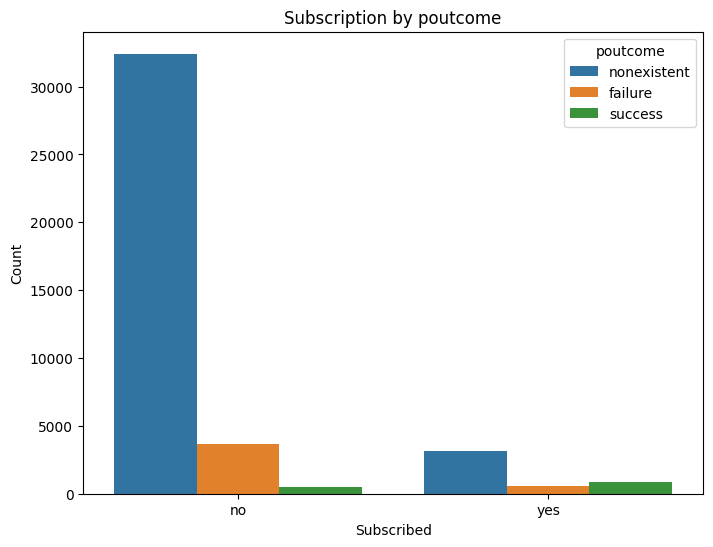

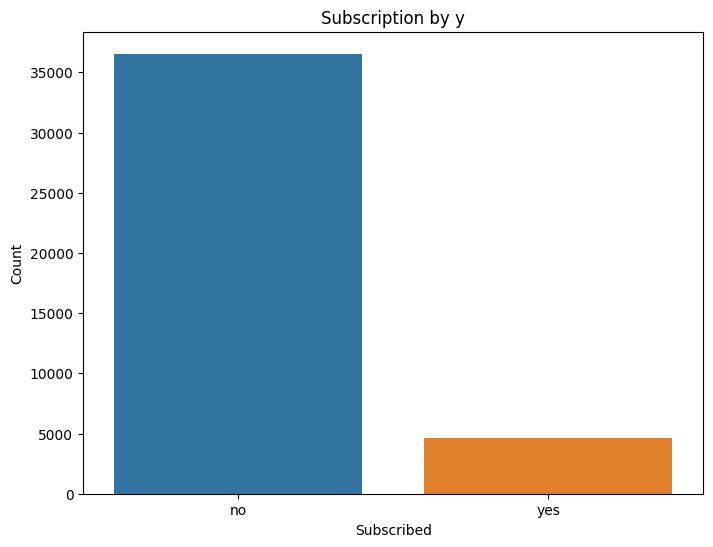

In [23]:
for column in df.select_dtypes(include=['object', 'category']).columns.tolist():
  plt.figure(figsize=(8, 6))
  sns.countplot(x='y', hue=column, data=df)
  plt.title(f'Subscription by {column}')
  plt.xlabel('Subscribed')
  plt.ylabel('Count')
  plt.show()

**Removing 'default' Feature due to extreme imbalance**

Given that only 3 out of 41,188 entries are 'yes', this column is highly unlikely to be a useful predictive feature and could even introduce noise or make the model marginally more complex without significant gain. It's generally a good practice to remove such columns as they add almost no information and can sometimes cause issues with certain algorithms or increase dimensionality unnecessarily.

In [24]:
df['default'].value_counts()

,count
default,
no,41185
yes,3


In [25]:
# Drop the 'default' column as it is highly imbalanced and provides little predictive power
df = df.drop(columns=['default'])
print(" 'default' column dropped successfully.")

 'default' column dropped successfully.


**Removing Duration Feature to avoid data leakage**

I will remove the `duration` column to avoid data leakage.

In [26]:
# Drop the 'duration' column as it causes data leakage for a realistic model
df = df.drop(columns=['duration'])

**Converting Target Variable**

Let's convert our target variable `y` to a numerical format for modeling and analyze the distribution of it.

In [27]:
# Convert 'y' (target variable) to numerical (0 for 'no', 1 for 'yes')
df['y'] = df['y'].map({'no': 0, 'yes': 1})

**Distribution of Target**

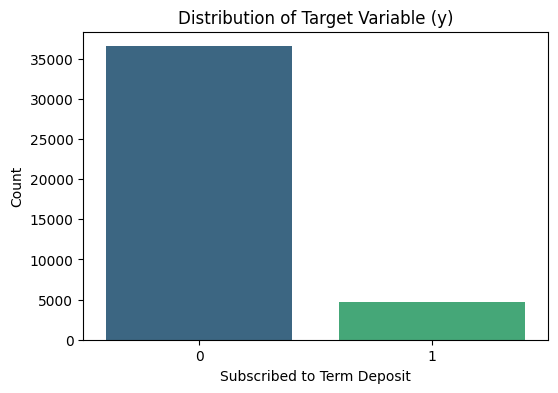

In [28]:
# Plot the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

The dataset is clearly imbalanced. To address this, I will use SMOTE in the subsequent steps to expand the minority class by increasing its sample count.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            41188 non-null  int64  
 1   job            41188 non-null  object 
 2   marital        41188 non-null  object 
 3   education      41188 non-null  object 
 4   housing        41188 non-null  object 
 5   loan           41188 non-null  object 
 6   contact        41188 non-null  object 
 7   month          41188 non-null  object 
 8   day_of_week    41188 non-null  object 
 9   campaign       41188 non-null  int64  
 10  pdays          41188 non-null  int64  
 11  previous       41188 non-null  int64  
 12  poutcome       41188 non-null  object 
 13  emp.var.rate   41188 non-null  float64
 14  cons.conf.idx  41188 non-null  float64
 15  y              41188 non-null  int64  
dtypes: float64(2), int64(5), object(9)
memory usage: 5.0+ MB


## Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [30]:
# Separate features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (41188, 15)
Shape of target (y): (41188,)


In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (32950, 15)
Shape of X_test: (8238, 15)
Shape of y_train: (32950,)
Shape of y_test: (8238,)


### More Feature Engineering

Now, we define the `ColumnTransformer`. It will handle:

*   **Numerical Features:** Imputation with the mean and `StandardScaler`.
*   **Low-Cardinality Categorical Features:** `OneHotEncoder`.
*   **High-Cardinality Categorical Features:** N/A

I'll use `remainder='passthrough'` to ensure any columns not explicitly mentioned in a transformer are kept, though in our `X_train` and `X_test` splits, the target is already separated.

**Defining a Column Transformer**

In [32]:
numeric_cols = X.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
       ('num', Pipeline(steps=[
                  ('imputer', SimpleImputer(strategy='mean')),
                  ('scaler', StandardScaler())
          ]), numeric_cols), # Applying to numerical columns
       ('cat', OneHotEncoder(), categorical_cols) # Applying to categorical columns
      ],
      remainder='passthrough' # Keep other columns that are not transformed (e.g., if there are any original columns not in above lists)
  )

- I use `fit_transform` ONLY on `X_train` to **learn** the parameters of the transformation.

- I use **only** `transform` on `X_test` to **apply** those same transformations, without recalculating the parameters. This ensures no data leakage and allows the model to **generalize** correctly.


In [33]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [34]:
numerical_column_names = numeric_cols

categorical_column_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)

all_column_names = list(numerical_column_names) + list(categorical_column_names)

# Convert the sparse matrixes into a DataFrame with the column names

X_train_processed_df = pd.DataFrame(X_train_processed.toarray(), columns=all_column_names)
X_test_processed_df = pd.DataFrame(X_test_processed.toarray(), columns=all_column_names)

X_train_processed_df.head(3), X_test_processed_df.head(3)

(        age  campaign     pdays  previous  emp.var.rate  cons.conf.idx  \
 0  0.863739  0.522981  0.196584 -0.350127     -0.114858      -0.322269   
 1 -0.289722 -0.203688  0.196584  1.653813     -0.114858      -0.322269   
 2  3.651268 -0.567023  0.196584 -0.350127     -1.133161       0.045048   
 
    job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  ...  \
 0         0.0              1.0               0.0            0.0  ...   
 1         0.0              0.0               1.0            0.0  ...   
 2         0.0              0.0               0.0            0.0  ...   
 
    month_oct  month_sep  day_of_week_fri  day_of_week_mon  day_of_week_thu  \
 0        0.0        0.0              0.0              0.0              0.0   
 1        0.0        0.0              0.0              0.0              0.0   
 2        0.0        0.0              0.0              1.0              0.0   
 
    day_of_week_tue  day_of_week_wed  poutcome_failure  poutcome_nonexistent  \
 0    

## Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

### Understanding Baseline Accuracy

Baseline accuracy is a fundamental metric in classification tasks. It represents the accuracy you would achieve if you simply predicted the majority class for every instance in your dataset. In highly imbalanced datasets, a model that simply predicts the majority class can achieve a seemingly high accuracy, even if it's not truly learning any patterns. Therefore, any machine learning model we build should ideally outperform this baseline accuracy to be considered useful.

The calculated baseline accuracy is: 0.8874


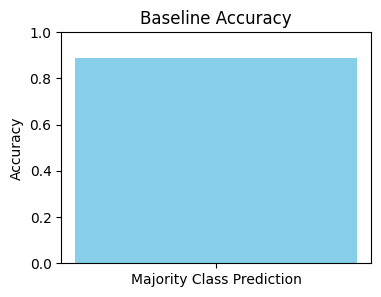

In [35]:
# Calculate the baseline accuracy by predicting the majority class
majority_class = y_train.value_counts().idxmax()
baseline_accuracy = (y_test == majority_class).mean()

print(f"The calculated baseline accuracy is: {baseline_accuracy:.4f}")

# You can also visualize it if you want, for instance with a bar chart
plt.figure(figsize=(4, 3))
plt.bar(['Majority Class Prediction'], [baseline_accuracy], color='skyblue')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.title('Baseline Accuracy')
plt.ylabel('Accuracy')
plt.show()

## Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [36]:
# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets

# Train the model and measure time
start_time = time.time()
log_reg_model.fit(X_train_processed_df, y_train)
end_time = time.time()
train_time = end_time - start_time

print(f"Logistic Regression Model Training Time: {train_time:.4f} seconds")

Logistic Regression Model Training Time: 0.1882 seconds


## Problem 9: Score the Model

What is the accuracy of your model?

### Accuracy

In [37]:
# Evaluate the model
train_accuracy = log_reg_model.score(X_train_processed_df, y_train)
test_accuracy = log_reg_model.score(X_test_processed_df, y_test)

print(f"Logistic Regression Training Accuracy: {train_accuracy:.4f}")
print(f"Logistic Regression Test Accuracy: {test_accuracy:.4f}")

Logistic Regression Training Accuracy: 0.8981
Logistic Regression Test Accuracy: 0.8986


### Classification Report

In [38]:
y_pred = log_reg_model.predict(X_test_processed_df)

print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred))


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.68      0.19      0.30       928

    accuracy                           0.90      8238
   macro avg       0.79      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238



### Confusion Matrix

In [39]:
def plot_confusion_matrix(model_name, y_pred, y_test):
  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['No Subscription', 'Subscription'],
              yticklabels=['No Subscription', 'Subscription'])
  plt.title(f'Confusion Matrix for {model_name}')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

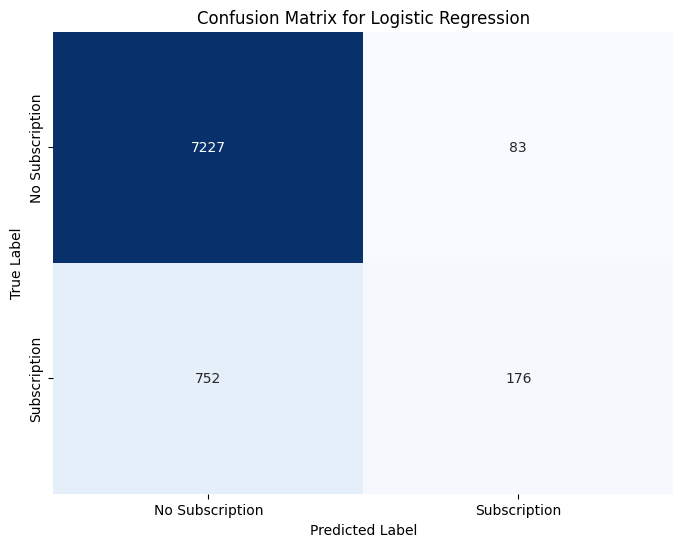

In [40]:
plot_confusion_matrix('Logistic Regression', y_pred, y_test)

### Key Takeaway

While the overall accuracy is high (0.90), the very low recall (0.19) and F1-score (0.30) for class 1 ('yes' subscription) indicate that the model is very poor at identifying customers who will subscribe. It mostly predicts 'no' because that's the majority class, leading to high accuracy but poor performance on the target class of interest for the business objective. This is a common issue with imbalanced datasets and is why I considered balancing the dataset with SMOTE.

## Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

**A Helper method to evaluate the given method and return a dictionary with results**

In [41]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
  model_name = model.__class__.__name__
  print(f"Evaluating {model_name}...")

  # Train the model and measure time
  start_time = time.time()
  model.fit(X_train, y_train)
  end_time = time.time()
  train_time = end_time - start_time
  #print(f"\n{model_name} Model Training Time: {train_time:.4f} seconds")

  # Training Accuracy
  train_accuracy = model.score(X_train, y_train)
  #print(f"\n{model_name} Training Accuracy: {train_accuracy:.4f}")

  # Test Accuracy
  test_accuracy = model.score(X_test, y_test)
  #print(f"\n{model_name}Test Accuracy: {test_accuracy:.4f}")

  # Predict
  y_pred = model.predict(X_test)

  # Generate classification report
  report = classification_report(y_test, y_pred, output_dict=True)
  #print(f"\n{model_name} Classification Report:")
  print(report)

  # Extract metrics for class 1
  recall_1 = report['1']['recall']
  precision_1 = report['1']['precision']
  f1_score_1 = report['1']['f1-score']

  # Return a dictionary with all metrics
  return {
      'Model': model_name,
      'Train Time': train_time,
      'Train Accuracy': train_accuracy,
      'Test Accuracy': test_accuracy,
      'Recall (Class 1)': recall_1,
      'Precision (Class 1)': precision_1,
      'F1-Score (Class 1)': f1_score_1
  }

**A Helper method to generate results for the given models**

In [42]:
def generate_model_results(models, X_train, y_train, X_test, y_test):
  model_results = pd.DataFrame(columns=['Model', 'Train Time', 'Train Accuracy', 'Test Accuracy', 'Recall (Class 1)', 'Precision (Class 1)', 'F1-Score (Class 1)'])
  for model in models:
    # Evaluate the model
    results = evaluate_model(model, X_train, y_train, X_test, y_test)
    # Add the results to the DataFrame
    model_results.loc[len(model_results)] = results
  return model_results


### Models - Default Versions

In [45]:
RANDOM_STATE = 42

In [46]:
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear')
# Initialize KNN model
knn_model = KNeighborsClassifier()
# Initialize Decision Tree model
decision_tree_model = DecisionTreeClassifier()
# Initialize SVC model
svc_model = SVC(random_state=RANDOM_STATE)

### Comparison

In [47]:
model_results = generate_model_results([log_reg_model, knn_model, decision_tree_model, svc_model],
                                       X_train_processed_df, y_train, X_test_processed_df, y_test)

display(model_results)

Evaluating LogisticRegression...
{'0': {'precision': 0.9057526005765133, 'recall': 0.9886456908344733, 'f1-score': 0.9453855713257898, 'support': 7310.0}, '1': {'precision': 0.6795366795366795, 'recall': 0.1896551724137931, 'f1-score': 0.2965459140690817, 'support': 928.0}, 'accuracy': 0.8986404467103666, 'macro avg': {'precision': 0.7926446400565964, 'recall': 0.5891504316241332, 'f1-score': 0.6209657426974358, 'support': 8238.0}, 'weighted avg': {'precision': 0.8802696708939489, 'recall': 0.8986404467103666, 'f1-score': 0.8722946266870153, 'support': 8238.0}}
Evaluating KNeighborsClassifier...
{'0': {'precision': 0.9133007460766658, 'recall': 0.9712722298221614, 'f1-score': 0.9413948554760011, 'support': 7310.0}, '1': {'precision': 0.5474137931034483, 'recall': 0.27370689655172414, 'f1-score': 0.3649425287356322, 'support': 928.0}, 'accuracy': 0.8926924010682205, 'macro avg': {'precision': 0.7303572695900571, 'recall': 0.6224895631869428, 'f1-score': 0.6531686921058166, 'support': 82

,Model,Train Time,Train Accuracy,Test Accuracy,Recall (Class 1),Precision (Class 1),F1-Score (Class 1)
0,LogisticRegression,0.200349,0.898118,0.898640,0.189655,0.679537,0.296546
1,KNeighborsClassifier,0.008388,0.912868,0.892692,0.273707,0.547414,0.364943
2,DecisionTreeClassifier,0.239547,0.992868,0.842802,0.346983,0.318497,0.332130
3,SVC,157.662825,0.901882,0.899854,0.183190,0.717300,0.291845


In this business context, 'class 1' denotes clients who subscribe to a term deposit. This class is prioritized because accurate identification of subscribers is the primary goal for revenue and growth. Due to the imbalanced nature of the data, models must be optimized for these rare 'yes' cases to avoid majority bias. While false positives result in wasted marketing resources, the cost of missed opportunities (false negatives) is considered more substantial.

Consequently, a model that maximizes true positives for 'class 1' is preferred for its direct impact on campaign success metrics.

### Balancing the dataset

In classification tasks, verifying data balance is essential to prevent models from developing a bias toward the majority class, which can lead to poor performance on underrepresented data. Ensuring a balanced dataset allows the model to learn from all classes equally, enhancing its generalization and accuracy for critical applications like fraud detection and medical diagnoses.

#### How to balance the data?
Mixing SMOTE (over-sampling) with Tomek Links (under-sampling) is widely considered one of the most sophisticated ways to handle imbalanced data. It is often referred to as SMOTETomek.

Here is why this "Hybrid" approach works so well for your stockout prediction:

#### The Strategy: "Fill and Clean"
- **The SMOTE Part:** First, the algorithm creates synthetic "Yes" cases to give the minority class more presence. However, SMOTE is "blind"—it often creates these synthetic points right in the middle of the "No" class territory, creating a messy, overlapping border.

- **The Tomek Links Part:** Then, the algorithm identifies "Tomek Links" (pairs of points from different classes that are each other's nearest neighbors). It removes the majority class member of these pairs.

- **The Result:** You get a balanced dataset with a wide, clear "No-Man's Land" between your stockouts and your regular orders. This makes it much easier for models like SVC and Decision Trees to find a reliable decision boundary.

#### Key considerations
- Always balance only the **training** set, not the test set.
- Compare model performance with and without balancing.
- Choose the balancing method carefully, as oversampling can lead to overfitting, and undersampling may lose important information.





In [48]:
# Initialize SMOTE
#smote = SMOTE(random_state=42)

smote = SMOTETomek(random_state=42)

# Apply SMOTE to balance the dataset
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed_df, y_train)

# Print the class distribution after balancing
print("Class distribution after SMOTE:", Counter(y_train_balanced))

Class distribution after SMOTE: Counter({0: 29076, 1: 29076})


**Running the same models with balanced data**

In [49]:
model_results_balanced = generate_model_results([log_reg_model, knn_model, decision_tree_model, svc_model],
                                       X_train_balanced, y_train_balanced, X_test_processed_df, y_test)

display(model_results_balanced)

Evaluating LogisticRegression...
{'0': {'precision': 0.9513606506099468, 'recall': 0.8321477428180575, 'f1-score': 0.8877699941622884, 'support': 7310.0}, '1': {'precision': 0.3345986984815618, 'recall': 0.6648706896551724, 'f1-score': 0.44516594516594515, 'support': 928.0}, 'accuracy': 0.8133042000485555, 'macro avg': {'precision': 0.6429796745457543, 'recall': 0.7485092162366149, 'f1-score': 0.6664679696641168, 'support': 8238.0}, 'weighted avg': {'precision': 0.8818832177894635, 'recall': 0.8133042000485555, 'f1-score': 0.8379112229230791, 'support': 8238.0}}
Evaluating KNeighborsClassifier...
{'0': {'precision': 0.9417773237997957, 'recall': 0.7567715458276334, 'f1-score': 0.8391990291262136, 'support': 7310.0}, '1': {'precision': 0.2478849407783418, 'recall': 0.6314655172413793, 'f1-score': 0.3560145808019441, 'support': 928.0}, 'accuracy': 0.7426559844622481, 'macro avg': {'precision': 0.5948311322890688, 'recall': 0.6941185315345064, 'f1-score': 0.5976068049640788, 'support': 82

,Model,Train Time,Train Accuracy,Test Accuracy,Recall (Class 1),Precision (Class 1),F1-Score (Class 1)
0,LogisticRegression,0.387622,0.734248,0.813304,0.664871,0.334599,0.445166
1,KNeighborsClassifier,0.026497,0.908137,0.742656,0.631466,0.247885,0.356015
2,DecisionTreeClassifier,0.800482,0.995890,0.837825,0.323276,0.297619,0.309917
3,SVC,212.821269,0.847520,0.876548,0.536638,0.458986,0.494784


It looks like it improved good but let's see if we can improve this more.

### Visualizing Model Comparisons

**Helper methods**

In [50]:
def add_value_labels(ax, is_horizontal=False, format_str='{:.2f}'):
    if is_horizontal:
        for bar in ax.patches:
            ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                    format_str.format(bar.get_width()),
                    ha='left', va='center', fontsize=9)
    else:
        for bar in ax.patches:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    format_str.format(bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

In [51]:
def visualize(model_results):
  fig, axes = plt.subplots(3, 2, figsize=(16, 20))

  sorted_results_train_acc = model_results.sort_values(by='Train Accuracy', ascending=False)
  sns.barplot(x='Model', y='Train Accuracy', data=sorted_results_train_acc, palette='coolwarm', ax=axes[0, 0])
  axes[0][0].set_title('Model Comparison: Training Accuracy')
  axes[0][0].set_ylabel('Training Accuracy')
  axes[0][0].set_xlabel('Model')
  axes[0][0].set_ylim(0, 1) # Accuracy is between 0 and 1
  axes[0][0].tick_params(axis='x', rotation=45)
  add_value_labels(axes[0][0])

  sorted_results_test_acc = model_results.sort_values(by='Test Accuracy', ascending=False)
  sns.barplot(x='Model', y='Test Accuracy', data=sorted_results_test_acc, palette='coolwarm', ax=axes[0, 1])
  axes[0][1].set_title('Model Comparison: Test Accuracy')
  axes[0][1].set_ylabel('Test Accuracy')
  axes[0][1].set_xlabel('Model')
  axes[0][1].set_ylim(0, 1) # Accuracy is between 0 and 1
  axes[0][1].tick_params(axis='x', rotation=45)
  add_value_labels(axes[0][1])

  sorted_results_precision = model_results.sort_values(by='Precision (Class 1)', ascending=False)
  sns.barplot(x='Model', y='Precision (Class 1)', data=sorted_results_precision, palette='coolwarm', ax=axes[1, 0])
  axes[1][0].set_title('Model Comparison: Precision (Class 1)')
  axes[1][0].set_ylabel('Precision (Class 1)')
  axes[1][0].set_xlabel('Model')
  axes[1][0].set_ylim(0, 1) # Score is between 0 and 1
  axes[1][0].tick_params(axis='x', rotation=45)
  add_value_labels(axes[1][0])

  sorted_results_recall = model_results.sort_values(by='Recall (Class 1)', ascending=False)
  sns.barplot(x='Model', y='Recall (Class 1)', data=sorted_results_recall, palette='coolwarm', ax=axes[1, 1])
  axes[1][1].set_title('Model Comparison: Recall (Class 1)')
  axes[1][1].set_ylabel('Recall (Class 1)')
  axes[1][1].set_xlabel('Model')
  axes[1][1].set_ylim(0, 1) # Score is between 0 and 1
  axes[1][1].tick_params(axis='x', rotation=45)
  add_value_labels(axes[1][1])

  sorted_results = model_results.sort_values(by='F1-Score (Class 1)', ascending=False)
  sns.barplot(x='Model', y='F1-Score (Class 1)', data=sorted_results, palette='coolwarm', ax=axes[2, 0])
  axes[2][0].set_title('Model Comparison: F1-Score (Class 1)')
  axes[2][0].set_ylabel('F1-Score (Class 1)')
  axes[2][0].set_xlabel('Model')
  axes[2][0].set_ylim(0, 1) # F1-score is between 0 and 1
  axes[2][0].tick_params(axis='x', rotation=45)
  add_value_labels(axes[2][0])

  # Sort the models by Train Time for the horizontal bar plot
  sorted_results_time = model_results.sort_values(by='Train Time', ascending=True)
  sns.barplot(x='Train Time', y='Model', data=sorted_results_time, palette='coolwarm', ax=axes[2, 1])
  axes[2][1].set_title('Model Comparison: Training Time (Horizontal Bar Plot, Log Scale)')
  axes[2][1].set_xlabel('Training Time (seconds, Log Scale)')
  axes[2][1].set_ylabel('Model')
  axes[2][1].set_xscale('log') # Apply logarithmic scale to the x-axis
  axes[2][1].tick_params(axis='x', rotation=45)
  add_value_labels(axes[2][1], is_horizontal=True, format_str='{:.4f}') # Use more precision for time

  plt.tight_layout()
  plt.show()

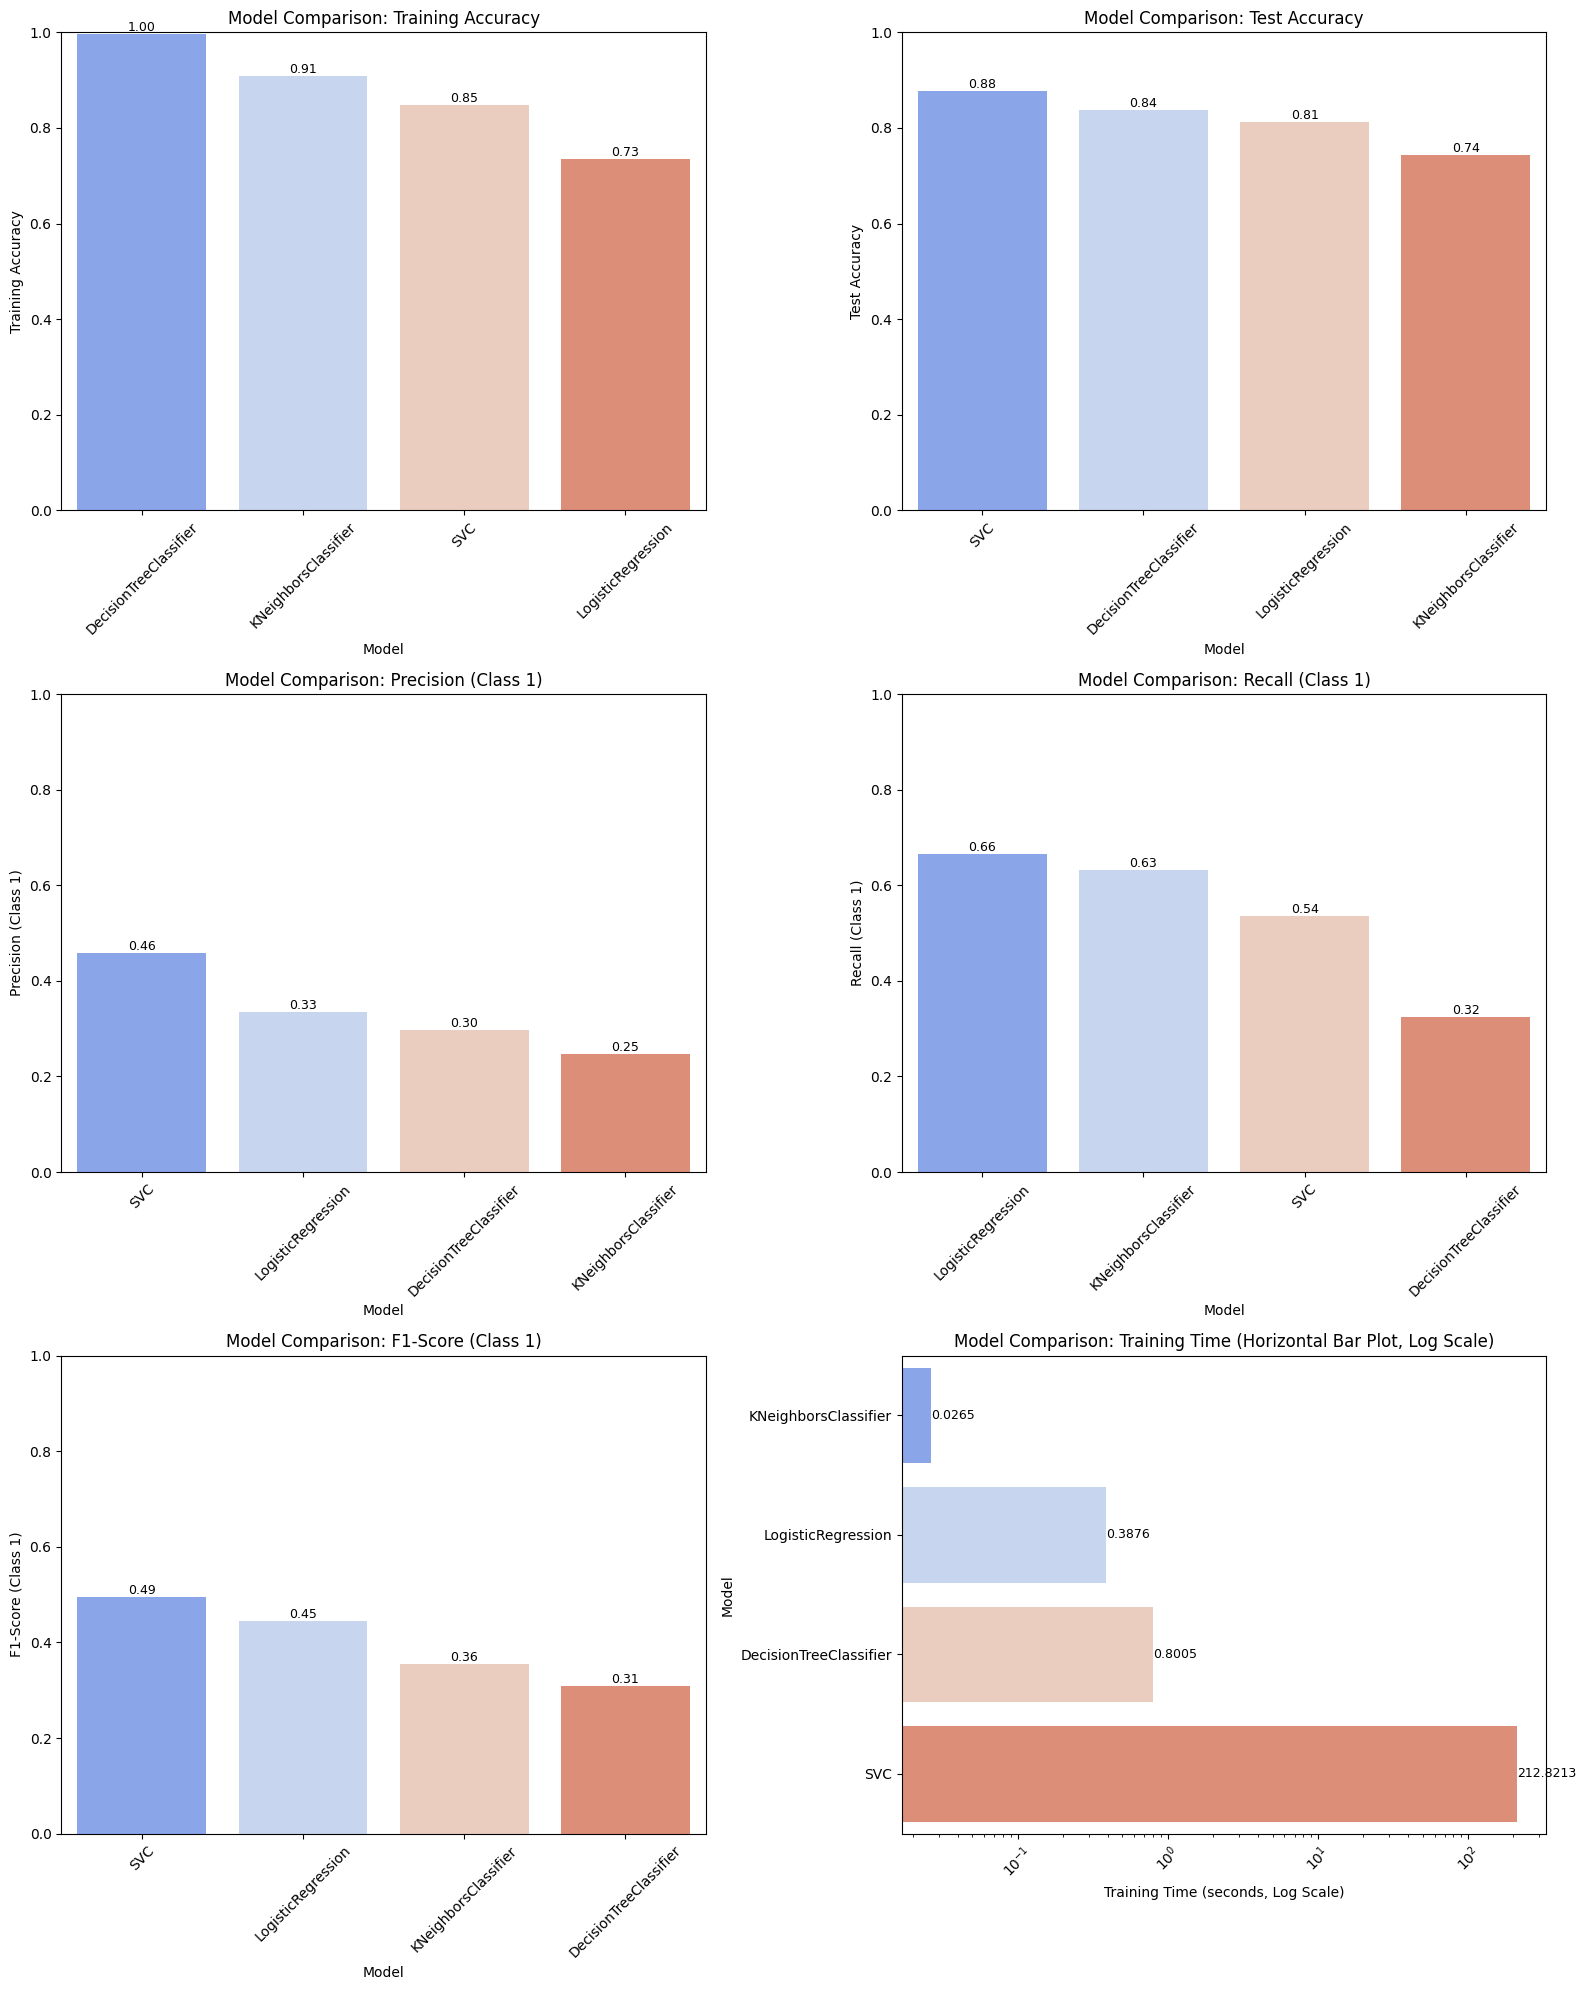

In [52]:
visualize(model_results_balanced)

An F1-score of 0.5 to 0.6 for the minority class is considered a reasonable result in complex, imbalanced scenarios like predicting subscription decisions (Though I tried to balance with syntetic data via SMOTE).

The primary objective is to maximize business value, which may involve accepting a lower F1-score in favor of higher recall to ensure more potential customers are captured.

## Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [53]:
def find_best(model, search_model, X_train, y_train):
  model_name = model.__class__.__name__
  print(f"Finding best parameters for {model_name}...")

  search_model_name = search_model.__class__.__name__

  print(f"Performing {search_model_name} for {model_name}")
  start_time_grid = time.time()
  search_model.fit(X_train, y_train)
  end_time_grid = time.time()

  #print(f"{search_model_name} for {model_name} completed in {(end_time_grid - start_time_grid):.2f} seconds")

  # Get the best parameters and best score
  best_params = search_model.best_params_
  best_score = search_model.best_score_

  print(f"Best parameters for {model_name}: {best_params}")
  #print(f"Best Recall on validation set: {best_score:.4f}\n")

  # Get the best estimator (tuned model)
  best_model = search_model.best_estimator_
  return best_model

### Hyperparameter Tuning for Logistic Regression

In [54]:
# Define the parameter grid for Logistic Regression
param_grid_lr = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    }
]

# Initialize GridSearchCV
grid_search = GridSearchCV(log_reg_model, param_grid_lr, cv=5, scoring='f1')

### Hyperparameter Tuning for K-Nearest Neighbors (KNN)

In [55]:
# Define the parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [5, 7, 9, 11], # Number of neighbors to use
    'weights': ['uniform', 'distance'], # Weight function used in prediction
    'metric': ['euclidean', 'manhattan']
}

# Initialize RandomizedSearchCV
randomized_search = RandomizedSearchCV(knn_model, param_grid_knn, cv=5, scoring='f1')

### Hyperparameter Tuning for Decision Tree

In [56]:
# Define the parameter grid for Decision Tree
param_grid_dt = {
    'class_weight': [None, 'balanced'],
    'max_depth': [10, 15, 20, 30, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 5],    # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy']  # Function to measure the quality of a split
}

# Initialize GridSearchCV
grid_search = GridSearchCV(decision_tree_model, param_grid_dt, cv=5, scoring='f1')

### Hyperparameter Tuning for Support Vector Classifier (SVC)

In [57]:
# Define the parameter grid for SVC
param_grid_svc = {
    'class_weight': [None, 'balanced'],
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto', 0.1]
}

# Initialize HalvingGridSearchCV
halving_search = HalvingGridSearchCV(svc_model, param_grid_svc, cv=3, scoring='f1')

**Results with tuned models with balanced data**

In [ ]:
# Finding the best logistic regression model
best_lr_model_with_balanced = find_best(log_reg_model, grid_search, X_train_balanced, y_train_balanced)

# Finding the best knn model
best_knn_model_with_balanced = find_best(knn_model, randomized_search, X_train_balanced, y_train_balanced)

# Finding the best model
best_dt_model_with_balanced = find_best(decision_tree_model, grid_search, X_train_balanced, y_train_balanced)

# Finding the best svc model
best_svc_model_with_balanced = find_best(svc_model, halving_search, X_train_balanced, y_train_balanced)

model_results_tuned_with_balanced = generate_model_results([best_lr_model_with_balanced, best_knn_model_with_balanced, best_dt_model_with_balanced, best_svc_model_with_balanced],
                                       X_train_balanced, y_train_balanced, X_test_processed, y_test)

display(model_results_tuned_with_balanced)
visualize(model_results_tuned_with_balanced)

Finding best parameters for LogisticRegression...
Performing GridSearchCV for LogisticRegression
Best parameters for LogisticRegression: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Finding best parameters for KNeighborsClassifier...
Performing RandomizedSearchCV for KNeighborsClassifier
Best parameters for KNeighborsClassifier: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}
Finding best parameters for DecisionTreeClassifier...
Performing GridSearchCV for DecisionTreeClassifier
Best parameters for DecisionTreeClassifier: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Finding best parameters for SVC...
Performing HalvingGridSearchCV for SVC


**Results with tuned models with not balanced data - using balance params**  

In [ ]:
# Finding the best logistic regression model
best_lr_model = find_best(log_reg_model, grid_search, X_train_processed, y_train)

# Finding the best knn model
best_knn_model = find_best(knn_model, randomized_search, X_train_processed, y_train)

# Finding the best model
best_dt_model = find_best(decision_tree_model, grid_search, X_train_processed, y_train)

# Finding the best svc model
best_svc_model = find_best(svc_model, halving_search, X_train_processed, y_train)

model_results_tuned = generate_model_results([best_lr_model, best_knn_model, best_dt_model, best_svc_model],
                                       X_train_processed, y_train, X_test_processed, y_test)

display(model_results_tuned)
visualize(model_results_tuned)

### Feature Importance for Tuned Model

Understanding feature importance helps in interpreting the model and identifying the most influential factors in predicting term deposit subscriptions. We will extract and visualize the feature importances from our best-tuned models.